In [1]:
%%time

#Would record: 0.9995程度
#ただ、データ自体、正解があいまいなものがあるようなので、これを目指すことはあまり意味がない

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, InputLayer
from keras.optimizers import RMSprop


# MNISTデータを読込む
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# MNISTデータを加工する

x_train = x_train.reshape(60000, 28, 28,1)
x_test = x_test.reshape(10000, 28, 28,1)
x_train  = x_train.astype('float32')
x_test   = x_test.astype('float32')
x_train /= 255
x_test  /= 255
y_train  = keras.utils.to_categorical(y_train, 10)
y_test   = keras.utils.to_categorical(y_test, 10)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LayerNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# --- データオーグメンテーション ---
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='constant',
    cval=0
)

datagen.fit(x_train)


activation = 'swish'

# --- モデル構築 ---
import numpy as np
wdecay = 1e-4  # L2正則化係数

model = Sequential()
model.add(InputLayer(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(3, 3),padding="same", activation= activation,kernel_regularizer=l2(wdecay)))
model.add(LayerNormalization())
model.add(Conv2D(32, kernel_size=(3, 3),padding="same", activation=activation,kernel_regularizer=l2(wdecay)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, kernel_size=(3, 3),padding="same", activation=activation,kernel_regularizer=l2(wdecay)))
model.add(LayerNormalization())
model.add(Conv2D(64, kernel_size=(3, 3),padding="same", activation=activation,kernel_regularizer=l2(wdecay)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.35))

model.add(Conv2D(128, kernel_size=(3, 3), padding="same",
                 activation=activation, kernel_regularizer=l2(wdecay)))
model.add(LayerNormalization())
model.add(Conv2D(128, kernel_size=(3, 3), padding="same",
                 activation=activation, kernel_regularizer=l2(wdecay)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Flatten())

model.add(Dense(64, activation=activation))

model.add(Dense(10, activation='softmax'))

# --- コンパイル ---
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    optimizer='adam',
    metrics=['accuracy']
)

# --- 学習 ---
batch_size = 64
epochs = 25

augmentation = datagen.flow(x_train, y_train, batch_size=batch_size)



history = model.fit(
    augmentation,
    epochs=epochs,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // batch_size,
)


# 検証
score = model.evaluate(x_test, y_test, verbose=1)
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.8927 - loss: 0.3684 - val_accuracy: 0.9846 - val_loss: 0.0939
Epoch 2/25
  1/937 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9531 - loss: 0.1922

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9531 - loss: 0.1922 - val_accuracy: 0.9853 - val_loss: 0.0916
Epoch 3/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9698 - loss: 0.1469 - val_accuracy: 0.9937 - val_loss: 0.0680
Epoch 4/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9688 - loss: 0.1234 - val_accuracy: 0.9939 - val_loss: 0.0679
Epoch 5/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9754 - loss: 0.1339 - val_accuracy: 0.9951 - val_loss: 0.0685
Epoch 6/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9844 - loss: 0.0914 - val_accuracy: 0.9951 - val_loss: 0.0686
Epoch 7/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9777 - loss: 0.1284 - val_accuracy: 0.9930 - val_loss: 0.0793
Epoch 8/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 0.0869 - val_accuracy: 0.9927 - val_loss: 0.0800
Epoch 9/25
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9801 - loss: 0.1229 - val_accuracy: 0.991

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


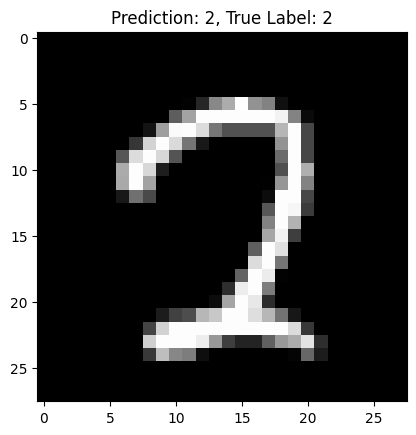

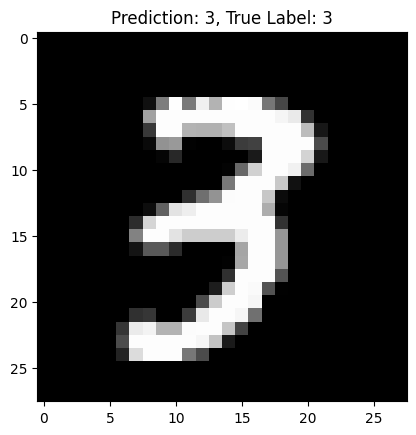

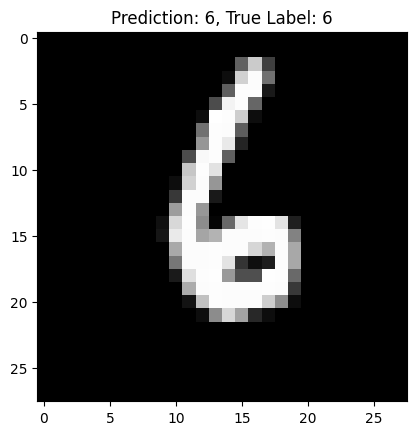

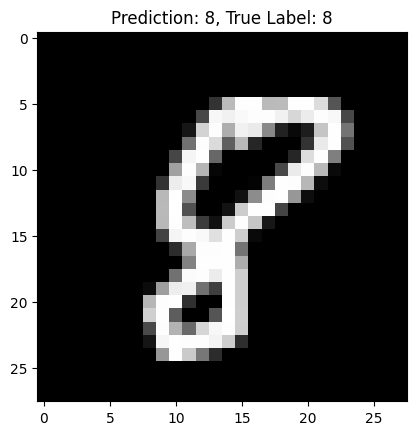

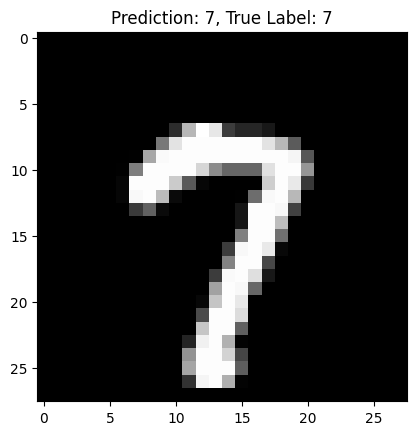

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# x_test: テストデータ
# y_test: 正解ラベル
# model: 評価対象のモデル

# テストデータに対する予測を取得
predictions = model.predict(x_test)

# いくつかの画像をランダムに選択
num_images_to_show = 5
random_indices = np.random.choice(len(x_test), size=num_images_to_show, replace=False)

# 画像と予測結果を表示
for i in random_indices:
    # 画像の表示
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'Prediction: {np.argmax(predictions[i])}, True Label: {np.argmax(y_test[i])}')
    plt.show()
